# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [0]:
from matplotlib import pyplot as plt
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.python.keras.applications.mobilenet import MobileNet
from tensorflow.python.keras.applications.mobilenet import preprocess_input

### Change directory

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
import os
os.chdir("/content/drive/My Drive/")

### Load the training data from train.csv file

In [0]:
#Read csv file as pandas dataframe
df_train = pd.read_csv('train_labels.csv')

### Print the shape of the train dataset

In [73]:
df_train.shape

(173, 8)

In [0]:
# There are 174 records and 9  features 

In [74]:
df_train.head(10)

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127
5,raccoon-69.jpg,205,246,raccoon,12,11,188,240
6,raccoon-180.jpg,600,400,raccoon,119,21,368,399
7,raccoon-200.jpg,261,193,raccoon,107,10,249,166
8,raccoon-141.jpg,249,202,raccoon,1,1,154,176
9,raccoon-19.jpg,259,194,raccoon,87,8,182,89


### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
image_size = 128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [0]:
 # Set the file-path for the images 
 df_train['path']= "Images/" + df_train['filename']

In [77]:
df_train.head(10)

,filename,width,height,class,xmin,ymin,xmax,ymax,path
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118,Images/raccoon-17.jpg
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431,Images/raccoon-11.jpg
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290,Images/raccoon-63.jpg
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298,Images/raccoon-63.jpg
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127,Images/raccoon-60.jpg
5,raccoon-69.jpg,205,246,raccoon,12,11,188,240,Images/raccoon-69.jpg
6,raccoon-180.jpg,600,400,raccoon,119,21,368,399,Images/raccoon-180.jpg
7,raccoon-200.jpg,261,193,raccoon,107,10,249,166,Images/raccoon-200.jpg
8,raccoon-141.jpg,249,202,raccoon,1,1,154,176,Images/raccoon-141.jpg
9,raccoon-19.jpg,259,194,raccoon,87,8,182,89,Images/raccoon-19.jpg


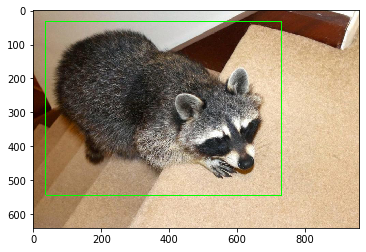

In [78]:
#Pickup a random image number
img_num = np.random.randint(0, df_train.shape[0])

#Read the image and draw a rectangle as per bounding box information
img = cv2.imread(df_train.loc[img_num,'path'])
cv2.rectangle(img, 
             (df_train.loc[img_num, 'xmin'],df_train.loc[img_num, 'ymin']),
             (df_train.loc[img_num, 'xmax'],df_train.loc[img_num, 'ymax']), 
             (0,255,0),
             2)
#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Draw image using matplotlib before down sample 128x128
plt.imshow(img)
plt.show()

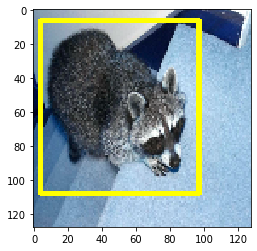

In [79]:
# To check how it is working after down sampling 
# Create a numpy arry to hold the images
d_images = np.zeros(shape=( image_size, image_size, 3))
# resize the image
img = tf.keras.preprocessing.image.load_img(df_train.loc[img_num, 'path'], 
                                                        target_size=(image_size, image_size))
#Conver to numpy array
img_array = tf.keras.preprocessing.image.img_to_array(img)
d_images = img_array
#Read and resize bounding box co-ordinates
img_width = df_train.loc[img_num, 'width']
img_height = df_train.loc[img_num, 'height']

xmin = int( df_train.loc[img_num, 'xmin'] * image_size/img_width)
xmax = int(df_train.loc[img_num, 'xmax'] * image_size/img_width)
ymin = int( df_train.loc[img_num, 'ymin'] * image_size/img_height )
ymax = int(df_train.loc[img_num, 'ymax'] * image_size/img_height)

cv2.rectangle(d_images, 
             (xmin,ymin),
             (xmax,ymax), 
             (0,255,255),
             2)
#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(d_images, cv2.COLOR_BGR2RGB)
#Draw image using matplotlib before down sample 128x128
plt.imshow(img.astype('uint8'))
plt.show()

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [0]:
# Use the batch generator to do the below tasks:
# Images: Read the Image-File into a numpy-array, reshape to 128*128*3, return a batch-set of batch_images 
# Bounding-Boxes: Get the batch-set of bounding-boxes adjusted to the reshaped-image and with coord (xmin, ymin, width, height)
def batch_generator(df, batch_size=32):

    while True:
        #Create indexes
        image_nums = np.random.randint(0,df.shape[0], size=batch_size)

        #Create empty arrays
        #1. To hold image input
        batch_images = np.zeros(shape=(batch_size, image_size,image_size, 3))
       
        #Regression labels - 4 numbers per example image
        batch_bboxes = np.zeros(shape=(batch_size, 4))

        for i in range(batch_size):

            #Read image and resize
            img = tf.keras.preprocessing.image.load_img(df.loc[image_nums[i], 'path'], 
                                                        target_size=(image_size, image_size))
            
            #Conver to numpy array
            img_array = tf.keras.preprocessing.image.img_to_array(img)

            #Update batch
            batch_images[i] = img_array

            #Read and resize bounding box co-ordinates
            img_width = df.loc[image_nums[i], 'width']
            img_height = df.loc[image_nums[i], 'height']
            
            xmin = df.loc[image_nums[i], 'xmin'] * image_size/img_width
            xmax = df.loc[image_nums[i], 'xmax'] * image_size/img_width

            ymin = df.loc[image_nums[i], 'ymin'] * image_size/img_height
            ymax = df.loc[image_nums[i], 'ymax'] * image_size/img_height

            #We will ask model to predict xmin, ymin, width and height of bounding box
            batch_bboxes[i] = [xmin, ymin, xmax-xmin, ymax-ymin]

        #Normalize batch images as per Pre-trained model to be used
        batch_images = preprocess_input(batch_images)
        
        #Make bounding boxes (x, y, w, h) as numbers between 0 and 1 - this seems to work better
        batch_bboxes = batch_bboxes/image_size

        #Return batch - use yield function to make it a python generator
        yield batch_images, batch_bboxes

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [0]:
#Load Pre-Trained Model
tf.keras.backend.clear_session()
model = MobileNet(include_top=False, #Do not include FC layer at the end
                      input_shape=(image_size,image_size, 3),
                      weights='imagenet')


In [82]:
print("Length of model",len(model.layers))

Length of model 87


In [83]:
# Model Summary
model.summary()

Model: "mobilenet_1.00_128"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 129, 129, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 64, 64, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 64, 64, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 64, 64, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 64, 64, 32) 

In [0]:
# Freeze all the layers
for layer in model.layers:
    layer.trainable = False

In [0]:
#get Output layer of Pre-trained model
x = model.output

# Add a convolution layer and batchnorm
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.BatchNormalization()(x)

#Flatten the output to feed to Dense layer
x = tf.keras.layers.Flatten()(x)

#Add Dropout
x = tf.keras.layers.Dropout(0.5)(x)

#Regression
bbox_output = tf.keras.layers.Dense(4 , activation='sigmoid', name='reg_op')(x)

Build layer for bounding box output


In [0]:
#Regression
bbox_output = tf.keras.layers.Dense(4 , activation='sigmoid', name='reg_op')(x)

Finalize the model

In [0]:
# Create a final-model with mobilenet and additional layers with output of bounding-box with 4 co-ordinates 
final_model = tf.keras.models.Model(inputs=model.input, #Pre-trained model input as input layer
                                    outputs= [bbox_output]) #Output layer added

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#    Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + tf.compat.v1.keras.backend.epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [0]:
# Final model
final_model.compile(optimizer='adam', 
                    loss={'reg_op':'mse'},
                    loss_weights={'reg_op':1},
                    metrics=[IoU]) 

In [0]:
#Create train-generation with batch-size of 32 
batchsize = 32
train_generator = batch_generator(df_train, batch_size=batchsize)

In [92]:
# Fit the model
final_model.fit_generator(train_generator, 
                          epochs=100,
                          steps_per_epoch= df_train.shape[0]/batchsize,
                          verbose=1)

Epoch 1/100
6/5 [=================================] - 58s 10s/step - loss: 0.0998 - IoU: 0.3700
Epoch 2/100
6/5 [=================================] - 18s 3s/step - loss: 0.0514 - IoU: 0.5373
Epoch 3/100
6/5 [=================================] - 9s 1s/step - loss: 0.0431 - IoU: 0.4862
Epoch 4/100
6/5 [=================================] - 9s 1s/step - loss: 0.0460 - IoU: 0.5395
Epoch 5/100
6/5 [=================================] - 7s 1s/step - loss: 0.0502 - IoU: 0.5238
Epoch 6/100
6/5 [=================================] - 7s 1s/step - loss: 0.0448 - IoU: 0.4996
Epoch 7/100
6/5 [=================================] - 7s 1s/step - loss: 0.0398 - IoU: 0.5153
Epoch 8/100
6/5 [=================================] - 7s 1s/step - loss: 0.0361 - IoU: 0.5474
Epoch 9/100
6/5 [=================================] - 7s 1s/step - loss: 0.0344 - IoU: 0.5635
Epoch 10/100
6/5 [=================================] - 7s 1s/step - loss: 0.0346 - IoU: 0.5640
Epoch 11/100
6/5 [=================================] - 7

In [0]:
# With 30 Epoch I am getting very bad result ( IoU = 0.5999). Hence I fixed 100 Epoch. 


In [0]:
final_model.save('mobnet_dataset.h5')

### Pick a test image from the given data, Resize to 128*128, Predict the Bounding-Box co-ordinates, show the image and the bouding-box


In [0]:
# Function to predict the bounding-box and draw the original and predicted bounding-box for a given test-image 
def predict_and_draw(image_num, df):

    #Load image
    img = tf.keras.preprocessing.image.load_img(df.loc[image_num, 'path'])
    w, h = img.size

    #Read bounding box
    xmin, ymin, xmax, ymax = df.loc[image_num, ['xmin', 'ymin', 'xmax', 'ymax']]
    
    #Prepare input for model
    #1. Resize image
    img_resized = img.resize((image_size, image_size)) 
    #2. Conver to array and make it a batch of 1
    input_array = tf.keras.preprocessing.image.img_to_array(img_resized)
    input_array = np.expand_dims(input_array, axis=0)
    #3. Normalize image data
    input_array = preprocess_input(input_array)

    #Prediction
    pred = final_model.predict(input_array)
    bbox_pred = pred[0]

    #Draw bounding boxes - Actual (Red) and Predicted(Green)
    img = cv2.imread(df.loc[image_num, 'path'])
    #Draw actual bounding box
    img = cv2.rectangle(img, (xmin, ymin), 
                       (xmax, ymax), (0,0,255), 2)
    #Draw predicted bounding box
    img = cv2.rectangle(img, (int(bbox_pred[0]*w), int(bbox_pred[1]*h)), 
                        (int((bbox_pred[0]+bbox_pred[2])*w), int((bbox_pred[1]+bbox_pred[3])*h)), (0,255,0), 2)

    #Display the picture
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()

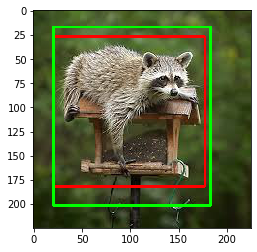

Draw bounding boxes - Ground Truth (Red) and Predicted(Green)


In [95]:
#Predict on Test Dataset
image_num = np.random.randint(0, df_train.shape[0])
predict_and_draw(image_num, df_train)
print("Draw bounding boxes - Ground Truth (Red) and Predicted(Green)")